# **Système de Recommandation LightGCN**


## **_Phase 1 :_** _Préparation et Exploration des Données_

> ### Dataset : MovieLens ml-latest-small

In [64]:
import os
import random
import pickle
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix, eye, block_diag
from scipy.sparse import save_npz, load_npz
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
from tqdm import tqdm


# Configuration globale 
warnings.filterwarnings('ignore') # Masquer les erreurs d'avertissement

sns.set_theme(style="whitegrid") # Style de tous les graphiques Seaborn
plt.rcParams['figure.figsize'] = (12, 5) # Taille de tousl les graphiques matplotlib

SEED = 42 # Valeur qui sert à fixer le génératuer de nombres aléatoires
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device : {DEVICE}")
print(f"GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"PyTorch : {torch.__version__}")
print("Imports OK!")

Device : cuda
GPU : Quadro M3000M
PyTorch : 2.3.0+cu121
Imports OK!


## 1. Chargement des données

In [16]:
# Chemin
DATA_PATH = '../data/ml-latest-small/'

# Chargement des fichiers CSV 
ratings = pd.read_csv(os.path.join(DATA_PATH, 'ratings.csv'))
movies  = pd.read_csv(os.path.join(DATA_PATH, 'movies.csv'))
tags    = pd.read_csv(os.path.join(DATA_PATH, 'tags.csv'))

# Aperçu rapide 
print(" RATINGS ")
print(f"Shape : {ratings.shape}")
print(f"Colonnes : {list(ratings.columns)}")
print(f"Mémoire : {ratings.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print(" MOVIES ")
print(f"Shape : {movies.shape}")
print(f"Colonnes : {list(movies.columns)}")
print()
print(" TAGS ")
print(f"Shape : {tags.shape}")
print(f"Colonnes : {list(tags.columns)}")
print()
print(ratings.head())

 RATINGS 
Shape : (100836, 4)
Colonnes : ['userId', 'movieId', 'rating', 'timestamp']
Mémoire : 3151.3 KB

 MOVIES 
Shape : (9742, 3)
Colonnes : ['movieId', 'title', 'genres']

 TAGS 
Shape : (3683, 4)
Colonnes : ['userId', 'movieId', 'tag', 'timestamp']

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


## 2. Statistiques descriptives

In [17]:
n_users  = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
density  = n_ratings / (n_users * n_movies) * 100
sparsity = 100 - density

print("STATISTIQUES GENERALES \n")

print(f"Nombre d'utilisateurs : {n_users:,}")
print(f"Nombre de films : {n_movies:,}")
print(f"Nombre de notes : {n_ratings:,}")
print(f"Note minimale : {ratings['rating'].min()}")
print(f"Note maximale : {ratings['rating'].max()}")
print(f"Note moyenne : {ratings['rating'].mean():.2f}")
print(f"Note mediane : {ratings['rating'].median():.1f}")

print(f"Densite du graphe : {density:.2f}%")
print(f"Sparsite du graphe : {sparsity:.2f}%")


STATISTIQUES GENERALES 

Nombre d'utilisateurs : 610
Nombre de films : 9,724
Nombre de notes : 100,836
Note minimale : 0.5
Note maximale : 5.0
Note moyenne : 3.50
Note mediane : 3.5
Densite du graphe : 1.70%
Sparsite du graphe : 98.30%


## 3. Analyse exploratoire (EDA)
### _3.1 Distribution des notes_

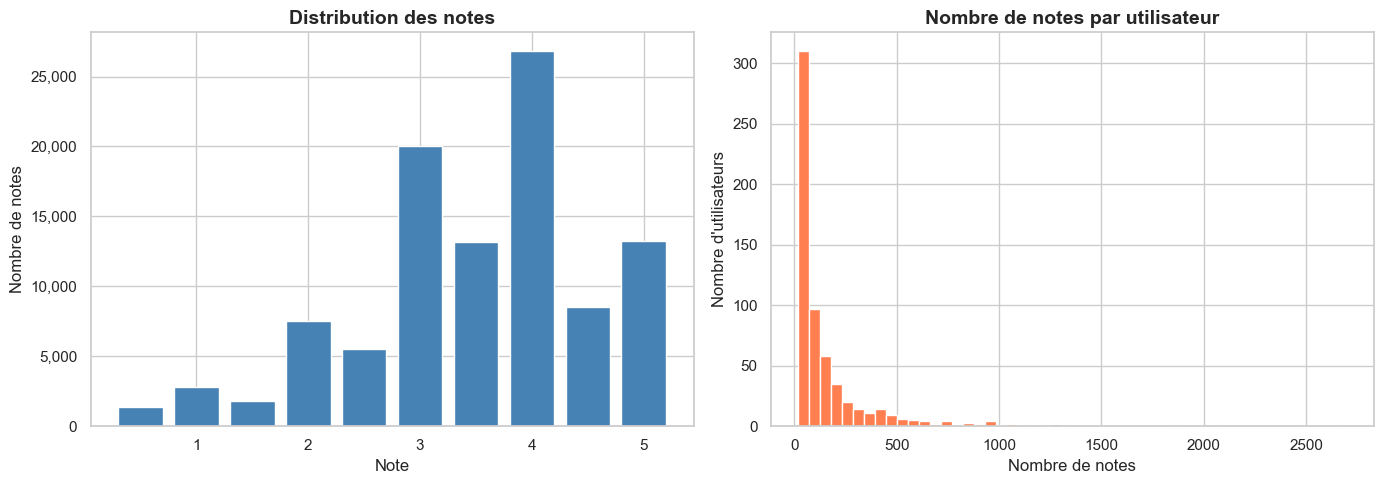

Notes par utilisateur :    Min : 20    Max : 2698    Moyenne : 165.3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : distribution des notes 
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, 
            width=0.4, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des notes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre de notes')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Graphique 2 : notes par utilisateur 
notes_par_user = ratings.groupby('userId')['rating'].count()
axes[1].hist(notes_par_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Nombre de notes par utilisateur', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de notes')
axes[1].set_ylabel('Nombre d\'utilisateurs')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../results/distribution_notes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Notes par utilisateur :    Min : {notes_par_user.min()}    Max : {notes_par_user.max()}    Moyenne : {notes_par_user.mean():.1f}")

### _3.2 Distribution des films_

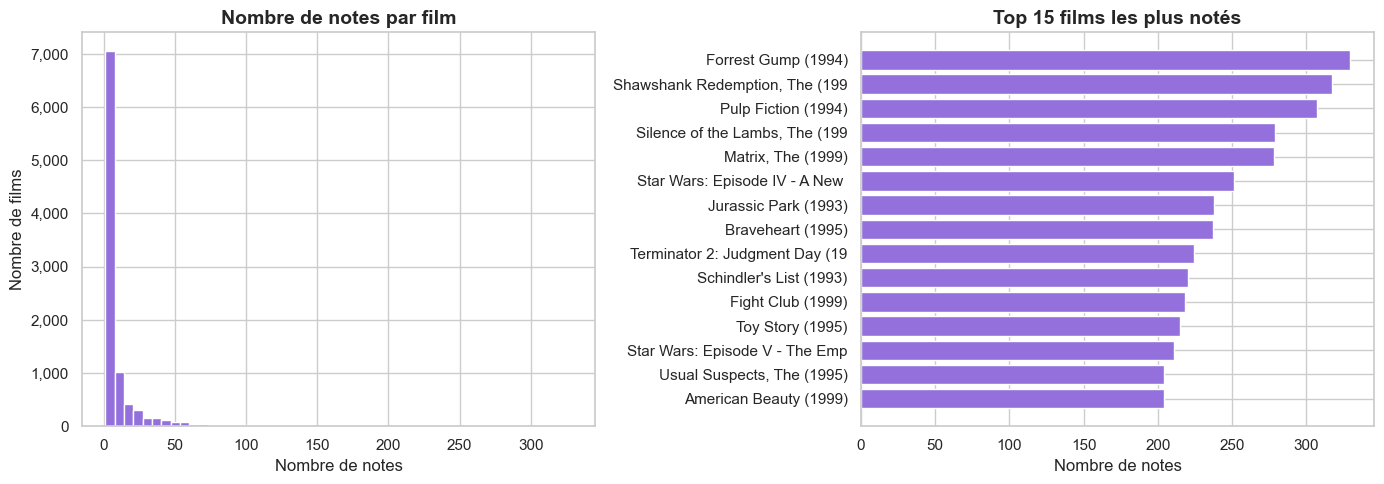

Notes par film :     Min : 1    Max : 329    Moyenne : 10.4


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : notes par film 
notes_par_film = ratings.groupby('movieId')['rating'].count()
axes[0].hist(notes_par_film, bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('Nombre de notes par film', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de notes')
axes[0].set_ylabel('Nombre de films')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Graphique 2 : Top 15 films les plus notés 
top_films = notes_par_film.sort_values(ascending=False).head(15)
top_films_df = top_films.reset_index()
top_films_df = top_films_df.merge(movies[['movieId', 'title']], on='movieId')
top_films_df['title'] = top_films_df['title'].str[:30]

axes[1].barh(top_films_df['title'][::-1], top_films_df['rating'][::-1],
             color='mediumpurple', edgecolor='white')
axes[1].set_title('Top 15 films les plus notés', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de notes')

plt.tight_layout()
plt.savefig('../results/distribution_films.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Notes par film :     Min : {notes_par_film.min()}    Max : {notes_par_film.max()}    Moyenne : {notes_par_film.mean():.1f}")

### _3.3 Analyse temporelle_

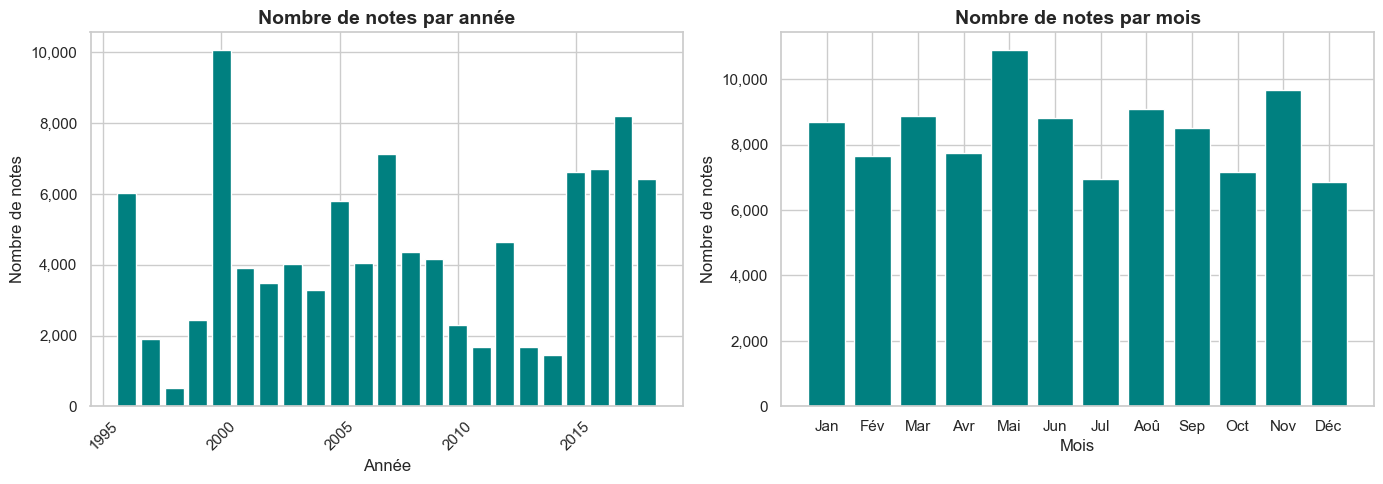

Période couverte : 1996 -> 2018


In [ ]:
# Conversion timestamp 
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['date'].dt.year
ratings['month'] = ratings['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : notes par année 
notes_par_annee = ratings.groupby('year').size()
axes[0].bar(notes_par_annee.index, notes_par_annee.values,
            color='teal', edgecolor='white')
axes[0].set_title('Nombre de notes par année', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre de notes')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

# Graphique 2 : notes par mois 
notes_par_mois = ratings.groupby('month').size()
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aoû','Sep','Oct','Nov','Déc']
axes[1].bar(mois_labels, notes_par_mois.values,
            color='teal', edgecolor='white')
axes[1].set_title('Nombre de notes par mois', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de notes')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../results/analyse_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Période couverte : {ratings['year'].min()} -> {ratings['year'].max()}")

## 4. Nettoyage et filtrage des données

In [21]:
print(" AVANT FILTRAGE")
print(f"Utilisateurs : {ratings['userId'].nunique():,}")
print(f"Films: {ratings['movieId'].nunique():,}")
print(f"Interactions : {len(ratings):,}")

# Seuil minimal : utilisateurs >= 20 notes, films >= 5 notes 
MIN_USER_RATINGS = 20
MIN_MOVIE_RATINGS = 5

# Filtrage itératif jusqu'à stabilisation
df = ratings[['userId', 'movieId', 'rating']].copy()
prev_len = -1

while prev_len != len(df):
    prev_len = len(df)
    # Filtre utilisateurs
    user_counts = df['userId'].value_counts()
    df = df[df['userId'].isin(user_counts[user_counts >= MIN_USER_RATINGS].index)]
    # Filtre films
    movie_counts = df['movieId'].value_counts()
    df = df[df['movieId'].isin(movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index)]

print("\n APRES FILTRAGE ")
print(f"Utilisateurs : {df['userId'].nunique():,}")
print(f"Films : {df['movieId'].nunique():,}")
print(f"Interactions : {len(df):,}")
print(f"\nInteractions supprimees : {len(ratings) - len(df):,}")
print(f"Taux de conservation : {len(df)/len(ratings)*100:.1f}%")

 AVANT FILTRAGE
Utilisateurs : 610
Films: 9,724
Interactions : 100,836

 APRES FILTRAGE 
Utilisateurs : 602
Films : 3,643
Interactions : 90,109

Interactions supprimees : 10,727
Taux de conservation : 89.4%


## 5. Réindexation des utilisateurs et des films

> Réindexation continue à partir de 0 

LightGCN a besoin d'indices continus 0, 1, 2, ... mais les `userId` et `movieId` originaux ont des trous après filtrage

In [22]:
# Liste triée de tous les utilisateurs et films uniques
unique_users  = sorted(df['userId'].unique())
unique_movies = sorted(df['movieId'].unique())

# Dictionnaires de mapping : ID original -> index continu (0, 1, 2, ...)
user2idx  = {u: i for i, u in enumerate(unique_users)}
movie2idx = {m: i for i, m in enumerate(unique_movies)}

# Dictionnaires inverses : index continu -> ID original
idx2user  = {i: u for u, i in user2idx.items()}
idx2movie = {i: m for m, i in movie2idx.items()}

# Application des mappings sur le dataframe
df['user_idx']  = df['userId'].map(user2idx)
df['movie_idx'] = df['movieId'].map(movie2idx)

# Stockage des dimensions du graphe
n_users  = len(unique_users)
n_movies = len(unique_movies)
n_interactions = len(df)

print(f"Nombre d'utilisateurs  : {n_users}")
print(f"Nombre de films: {n_movies}")
print(f"Nombre d'interactions  : {n_interactions:,}")
print(f"\nuser_idx  : {df['user_idx'].min()} -> {df['user_idx'].max()}")
print(f"movie_idx : {df['movie_idx'].min()} -> {df['movie_idx'].max()}")
print("\nApercu :")
print(df[['userId','user_idx','movieId','movie_idx','rating']].head())

Nombre d'utilisateurs  : 602
Nombre de films: 3643
Nombre d'interactions  : 90,109

user_idx  : 0 -> 601
movie_idx : 0 -> 3642

Apercu :
   userId  user_idx  movieId  movie_idx  rating
0       1         0        1          0     4.0
1       1         0        3          2     4.0
2       1         0        6          5     4.0
3       1         0       47         40     5.0
4       1         0       50         42     5.0


## 6. Split temporel train / validation / test

> On trie les interactions de chaque utilisateur par date.

Les plus anciennes -> train, les plus récentes -> test. Cela simule un vrai scénario : on prédit le futur à partir du passé

In [ ]:
# Tri par timestamp pour respecter la temporalité
df_sorted = df.merge(
    ratings[['userId', 'movieId', 'timestamp']],
    on=['userId', 'movieId'],
    how='left'
).sort_values(['user_idx', 'timestamp'])

# Split par utilisateur : 80% train / 10% val / 10% test 
train_data = []
val_data = []
test_data = []

for user_idx, group in df_sorted.groupby('user_idx'):
    n= len(group)
    n_train= max(1, int(0.8 * n))
    n_val= max(1, int(0.1 * n))

    train_data.append(group.iloc[:n_train])
    val_data.append(group.iloc[n_train:n_train + n_val])
    test_data.append(group.iloc[n_train + n_val:])

train_df = pd.concat(train_data).reset_index(drop=True)
val_df= pd.concat(val_data).reset_index(drop=True)
test_df = pd.concat(test_data).reset_index(drop=True)

# Résumé 
total = len(train_df) + len(val_df) + len(test_df)
print(" SPLIT TRAIN / VAL / TEST \n")
print(f"Train : {len(train_df):,}  ({len(train_df)/total*100:.1f}%)")
print(f"Val: {len(val_df):,}  ({len(val_df)/total*100:.1f}%)")
print(f"Test : {len(test_df):,}  ({len(test_df)/total*100:.1f}%)")
print(f"Total : {total:,}")
print(f"\nVerification : {total == len(df)}")

 SPLIT TRAIN / VAL / TEST 

Train : 71,842  (79.7%)
Val: 8,761  (9.7%)
Test : 9,506  (10.5%)
Total : 90,109

Verification : True


## 7. Construction du graphe biparti utilisateur-film

> On utilise uniquement le train pour construire le graphe.

Val et test servent uniquement à l'évaluation

> Matrice creuse utilisateur x film (1 = interaction, 0 = pas d'interaction)

In [24]:
# Construction de la matrice d'interaction
row = train_df['user_idx'].values   # indices utilisateurs
col = train_df['movie_idx'].values  # indices films
data = np.ones(len(train_df))       # 1 pour chaque interaction

# Matrice creuse de taille (n_users x n_movies)
interaction_matrix = csr_matrix(
    (data, (row, col)),
    shape=(n_users, n_movies)
)

print(" MATRICE D'INTERACTION ")
print(f"Dimensions: {interaction_matrix.shape}")
print(f"Interactions: {interaction_matrix.nnz:,}")
print(f"Densite: {interaction_matrix.nnz / (n_users * n_movies) * 100:.2f}%")
print(f"Type: {type(interaction_matrix)}")

#  Dictionnaire train : user -> set de films vus 
# Utilisé pendant l'entraînement pour l'échantillonnage négatif
train_user_items = {}
for _, row_data in train_df.iterrows():
    u = int(row_data['user_idx'])
    m = int(row_data['movie_idx'])
    if u not in train_user_items:
        train_user_items[u] = set()
    train_user_items[u].add(m)

# Dictionnaire test : user -> set de films à prédire
test_user_items = {}
for _, row_data in test_df.iterrows():
    u = int(row_data['user_idx'])
    m = int(row_data['movie_idx'])
    if u not in test_user_items:
        test_user_items[u] = set()
    test_user_items[u].add(m)

print(f"\nUtilisateurs dans train_user_items : {len(train_user_items)}")
print(f"Utilisateurs dans test_user_items  : {len(test_user_items)}")
print(f"\nExemple: L' utilisateur 0 a vu {len(train_user_items[0])} films dans le trainset")

 MATRICE D'INTERACTION 
Dimensions: (602, 3643)
Interactions: 71,842
Densite: 3.28%
Type: <class 'scipy.sparse._csr.csr_matrix'>

Utilisateurs dans train_user_items : 602
Utilisateurs dans test_user_items  : 602

Exemple: L' utilisateur 0 a vu 181 films dans le trainset


## 8. Sauvegarde des données préprocessées

In [ ]:
# Sauvegarde des dataframes
train_df.to_csv('../data/train.csv', index=False)
val_df.to_csv('../data/val.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)

# Sauvegarde des mappings et dictionnaires
preprocessed = {
    'n_users' : n_users,
    'n_movies' : n_movies,
    'user2idx' : user2idx,
    'movie2idx' : movie2idx,
    'idx2user' : idx2user,
    'idx2movie' : idx2movie,
    'train_user_items' : train_user_items,
    'test_user_items' : test_user_items,
}

with open('../data/preprocessed.pkl', 'wb') as f:
    pickle.dump(preprocessed, f)

# Sauvegarde de la matrice d'interaction 
save_npz('../data/interaction_matrix.npz', interaction_matrix)

# Vérification 
fichiers = ['train.csv', 'val.csv', 'test.csv',
            'preprocessed.pkl', 'interaction_matrix.npz']

print(" FICHIERS SAUVEGARDES ")
for f in fichiers:
    path = f'../data/{f}'
    size = os.path.getsize(path) / 1024
    print(f" {f}   {size:.1f} KB")

print("\nSauvegarde OK ")

 FICHIERS SAUVEGARDES 
 train.csv   2303.8 KB
 val.csv   283.4 KB
 test.csv   308.8 KB
 preprocessed.pkl   359.2 KB
 interaction_matrix.npz   139.4 KB

Sauvegarde OK 


## **_Phase 2 :_** _Implémentation du modèle LightGCN_

## 1. Chargement des données préprocessées

In [ ]:
# Chargement des mappings et dictionnaires 
with open('../data/preprocessed.pkl', 'rb') as f:
    preprocessed = pickle.load(f)

n_users = preprocessed['n_users']
n_movies = preprocessed['n_movies']
user2idx = preprocessed['user2idx']
movie2idx = preprocessed['movie2idx']
idx2user = preprocessed['idx2user']
idx2movie = preprocessed['idx2movie']
train_user_items = preprocessed['train_user_items']
test_user_items = preprocessed['test_user_items']

# Chargement de la matrice d'interaction
interaction_matrix = load_npz('../data/interaction_matrix.npz')

# Chargement des splits 
train_df = pd.read_csv('../data/train.csv')
val_df = pd.read_csv('../data/val.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Utilisateurs : {n_users}")
print(f"Films : {n_movies}")
print(f"Matrice : {interaction_matrix.shape}")
print(f"Train : {len(train_df):,}")
print(f"Val : {len(val_df):,}")
print(f"Test : {len(test_df):,}")
print("\nChargement terminé")

Utilisateurs : 602
Films : 3643
Matrice : (602, 3643)
Train : 71,842
Val : 8,761
Test : 9,506

Chargement terminé


## 2. Construction de la matrice d'adjacence normalisée

LightGCN travaille sur un graphe biparti utilisateur-film.

La matrice d'adjacence A est construite comme suit :

A = [0, R][R^T, 0] où R est la matrice d'interaction (n_users x n_movies); A est de taille (n_users + n_movies) x (n_users + n_movies)

In [ ]:
# Construction de la matrice d'adjacence symétrique 
R = interaction_matrix  # (602 x 3643)

# Blocs de zéros
zeros_users  = sp.csr_matrix((n_users, n_users))
zeros_movies = sp.csr_matrix((n_movies, n_movies))

# Construction par blocs
A = sp.bmat([
    [zeros_users, R],
    [R.T, zeros_movies]
], format='csr')

print(f"Matrice A (avant normalisation) :")
print(f" Dimensions : {A.shape}")
print(f" Non-zeros : {A.nnz:,}")

# Normalisation symétrique D^(-1/2) A D^(-1/2) avec D est la matrice diagonale des degrés des noeuds

# Calcul du degré de chaque noeud
rowsum = np.array(A.sum(axis=1)).flatten()

# D^(-1/2) : inverse de la racine carrée des degrés
d_inv_sqrt = np.power(rowsum, -0.5)
d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0  # évite les divisions par zéro

# Matrice diagonale D^(-1/2)
D_inv_sqrt = sp.diags(d_inv_sqrt)

# Matrice normalisée : A_norm = D^(-1/2) * A * D^(-1/2)
A_norm = D_inv_sqrt @ A @ D_inv_sqrt
A_norm = A_norm.tocsr()

print(f"\nMatrice A_norm (apres normalisation) :")
print(f" Dimensions : {A_norm.shape}")
print(f" Non-zeros : {A_norm.nnz:,}")
print(f" Min valeur : {A_norm.data.min():.6f}")
print(f" Max valeur : {A_norm.data.max():.6f}")

#  Conversion en tenseur PyTorch sparse (utile pour le passage de messages)
A_norm_coo = A_norm.tocoo()

indices = torch.LongTensor(
    np.vstack([A_norm_coo.row, A_norm_coo.col])
)
values  = torch.FloatTensor(A_norm_coo.data)
shape   = torch.Size(A_norm_coo.shape)

adj_matrix = torch.sparse_coo_tensor(indices, values, shape).to(DEVICE)

print(f"\nTenseur sparse PyTorch :")
print(f" Shape : {adj_matrix.shape}")
print(f" Device : {adj_matrix.device}")
print("\nMatrice d'adjacence OK")

Matrice A (avant normalisation) :
 Dimensions : (4245, 4245)
 Non-zeros : 143,684

Matrice A_norm (apres normalisation) :
 Dimensions : (4245, 4245)
 Non-zeros : 143,684
 Min valeur : 0.001391
 Max valeur : 0.204124

Tenseur sparse PyTorch :
 Shape : torch.Size([4245, 4245])
 Device : cuda:0

Matrice d'adjacence OK


## 3. Implémentation de la classe LightGCN

In [ ]:
class LightGCN(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=64, n_layers=3):
        super(LightGCN, self).__init__()

        self.n_users = n_users
        self.n_movies = n_movies
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers

        # Embeddings initiaux (couche 0) 
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)

        # Initialisation Xavier (pour eviter les gradients qui explosent ou disparaissent)
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.movie_embedding.weight)

    def forward(self, adj_matrix):
        # Concaténation des embeddings initiaux
        # Vecteur de taille (n_users + n_movies) x embedding_dim
        all_embeddings = torch.cat([
            self.user_embedding.weight,
            self.movie_embedding.weight
        ], dim=0)

        # Propagation sur K couches 
        embeddings_list = [all_embeddings]

        for _ in range(self.n_layers):
            # Passage de messages : A_norm * E
            all_embeddings = torch.sparse.mm(adj_matrix, all_embeddings)
            embeddings_list.append(all_embeddings)

        # Combinaison finale : moyenne de toutes les couches 
        final_embeddings = torch.stack(embeddings_list, dim=1).mean(dim=1)

        # Séparation utilisateurs / films
        user_embeddings = final_embeddings[:self.n_users]
        movie_embeddings = final_embeddings[self.n_users:]

        return user_embeddings, movie_embeddings

    def get_user_embedding(self, user_indices):
        # Retourne les embeddings initiaux d'un batch d'utilisateurs
        return self.user_embedding(user_indices)

    def get_movie_embedding(self, movie_indices):
        # Retourne les embeddings initiaux d'un batch de films
        return self.movie_embedding(movie_indices)

## 4. Test de l'architecture

In [38]:
# Instanciation du modèle 
model = LightGCN(
    n_users = n_users,
    n_movies = n_movies,
    embedding_dim = 64,
    n_layers = 3
).to(DEVICE)

# Résumé de l'architecture 
print(" ARCHITECTURE LIGHTGCN")
print(f"Utilisateurs : {n_users}")
print(f"Films : {n_movies}")
print(f"Dimension embed : 64")
print(f"Nombre de couches : 3")
print(f"Device : {next(model.parameters()).device}")

# Nombre de paramètres
total_params = sum(p.numel() for p in model.parameters())
print(f"\nParamètres totaux : {total_params:,}")
print(f" user_embedding : {model.user_embedding.weight.shape}")
print(f" movie_embedding : {model.movie_embedding.weight.shape}")

# Test du forward pass
model.eval()
with torch.no_grad():
    user_emb, movie_emb = model(adj_matrix)

print("\n TEST FORWARD PASS ")
print(f"user_emb shape : {user_emb.shape}")
print(f"movie_emb shape : {movie_emb.shape}")

# Test de recommandation pour un utilisateur 
test_user = 0
scores = torch.matmul(user_emb[test_user], movie_emb.T)
top10 = torch.topk(scores, k=10)

print(f"\n TOP 10 FILMS POUR UTILISATEUR {test_user} (avant entrainement) ")
for rank, (score, movie_idx) in enumerate(
    zip(top10.values.cpu(), top10.indices.cpu()), 1
):
    original_movie_id = idx2movie[movie_idx.item()]
    title = movies[movies['movieId'] == original_movie_id]['title'].values[0]
    print(f"  {rank:>2}. {title[:40]}  ---  score : {score:.4f}")

print("\nTest architecture OK")
print(" Phase 2 terminée!!")

 ARCHITECTURE LIGHTGCN
Utilisateurs : 602
Films : 3643
Dimension embed : 64
Nombre de couches : 3
Device : cuda:0

Paramètres totaux : 271,680
 user_embedding : torch.Size([602, 64])
 movie_embedding : torch.Size([3643, 64])

 TEST FORWARD PASS 
user_emb shape : torch.Size([602, 64])
movie_emb shape : torch.Size([3643, 64])

 TOP 10 FILMS POUR UTILISATEUR 0 (avant entrainement) 
   1. Pelican Brief, The (1993)  ---  score : 0.0025
   2. Village of the Damned (1960)  ---  score : 0.0023
   3. Shampoo (1975)  ---  score : 0.0022
   4. Tokyo Godfathers (2003)  ---  score : 0.0022
   5. Newsies (1992)  ---  score : 0.0022
   6. Celebrity (1998)  ---  score : 0.0021
   7. Gallipoli (1981)  ---  score : 0.0021
   8. Very Bad Things (1998)  ---  score : 0.0021
   9. Sweet Home Alabama (2002)  ---  score : 0.0020
  10. Insomnia (2002)  ---  score : 0.0020

Test architecture OK
 Phase 2 terminée!!


## _**Phase 3** : Entraînement du modèle_
## 1. Fonction de perte BPR (Bayesian Personalized Ranking)

In [39]:
def bpr_loss(user_emb_0, pos_emb_0, neg_emb_0,
             user_emb_f, pos_emb_f, neg_emb_f,
             lambda_reg=1e-4):
    """
    Calcule la perte BPR + régularisation L2.

    Paramètres :
    - user_emb_0 : embeddings initiaux des utilisateurs (couche 0)
    - pos_emb_0 : embeddings initiaux des films positifs (vus)
    - neg_emb_0 : embeddings initiaux des films négatifs (non vus)
    - user_emb_f : embeddings finaux des utilisateurs (après propagation)
    - pos_emb_f : embeddings finaux des films positifs
    - neg_emb_f : embeddings finaux des films négatifs
    - lambda_reg : coefficient de régularisation L2
    """

    # Scores de préférence
    # Score positif : similarité utilisateur-film vu
    pos_scores = (user_emb_f * pos_emb_f).sum(dim=1)

    # Score négatif : similarité utilisateur-film non vu
    neg_scores = (user_emb_f * neg_emb_f).sum(dim=1)

    # Perte BPR 
    # On maximise la différence pos_score - neg_score
    bpr = -torch.log(torch.sigmoid(pos_scores - neg_scores)).mean()

    # Régularisation L2 sur les embeddings initiaux (uniquement sur la couche 0 pour éviter l'overfitting)
    reg = (user_emb_0.norm(2).pow(2) +
           pos_emb_0.norm(2).pow(2) +
           neg_emb_0.norm(2).pow(2)) / (2 * len(user_emb_0))

    return bpr + lambda_reg * reg, bpr.item(), reg.item()

## 2. Échantillonnage négatif
Pour chaque utilisateur du batch, sélectionne aléatoirement un film qu'il n'a PAS vu (échantillon négatif).

In [40]:
def negative_sampling(batch_users, train_user_items, n_movies):

    neg_items = []

    for user in batch_users:
        # Films déjà vus par cet utilisateur
        seen = train_user_items[user]

        # Tire aléatoirement jusqu'à trouver un film non vu
        while True:
            neg = random.randint(0, n_movies - 1)
            if neg not in seen:
                neg_items.append(neg)
                break

    return torch.LongTensor(neg_items).to(DEVICE)

## 3. Boucle d'entraînement

In [41]:
# Hyperparamètres d'entraînement
N_EPOCHS = 50
BATCH_SIZE = 1024
LR = 1e-3
LAMBDA_REG = 1e-4
K = 20  # Top-K pour l'évaluation

# Réinitialisation du modèle 
model = LightGCN(
    n_users = n_users,
    n_movies = n_movies,
    embedding_dim = 64,
    n_layers = 3
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Préparation des données d'entraînement
train_users = torch.LongTensor(train_df['user_idx'].values).to(DEVICE)
train_movies = torch.LongTensor(train_df['movie_idx'].values).to(DEVICE)

n_train = len(train_df)

# Historique des métriques
history = {
    'loss' : [],
    'bpr' : [],
    'reg' : [],
    'recall' : [],
    'ndcg' : [],
}

print(f"Début entraînement : {N_EPOCHS} epochs | batch={BATCH_SIZE} | lr={LR}")
print(f"Interactions train : {n_train:,}")
print(f"Device : {DEVICE}")

# Boucle principale 
for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    total_bpr = 0.0
    total_reg = 0.0

    # Mélange des données à chaque epoch
    perm = torch.randperm(n_train)
    train_users_shuf = train_users[perm]
    train_movies_shuf = train_movies[perm]

    # Mini-batches
    n_batches = (n_train + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in range(n_batches):
        start = batch_idx * BATCH_SIZE
        end = min(start + BATCH_SIZE, n_train)

        batch_users = train_users_shuf[start:end]
        batch_pos = train_movies_shuf[start:end]
        batch_neg = negative_sampling(
                        batch_users.cpu().tolist(),
                        train_user_items,
                        n_movies
                        )

        # Forward pass
        user_emb_f, movie_emb_f = model(adj_matrix)

        # Embeddings finaux du batch
        u_emb_f = user_emb_f[batch_users]
        pos_emb_f = movie_emb_f[batch_pos]
        neg_emb_f = movie_emb_f[batch_neg]

        # Embeddings initiaux du batch (pour régularisation)
        u_emb_0 = model.user_embedding(batch_users)
        pos_emb_0 = model.movie_embedding(batch_pos)
        neg_emb_0 = model.movie_embedding(batch_neg)

        # Calcul de la perte
        loss, bpr, reg = bpr_loss(
            u_emb_0, pos_emb_0, neg_emb_0,
            u_emb_f, pos_emb_f, neg_emb_f,
            LAMBDA_REG
        )

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bpr += bpr
        total_reg += reg

    # Moyenne sur les batches
    avg_loss = total_loss / n_batches
    avg_bpr = total_bpr / n_batches
    avg_reg = total_reg / n_batches

    history['loss'].append(avg_loss)
    history['bpr'].append(avg_bpr)
    history['reg'].append(avg_reg)

    # Affichage toutes les 5 epochs
    if epoch % 5 == 0:
        print(f"Epoch {epoch}/{N_EPOCHS} | "
              f"Loss : {avg_loss:.4f} | "
              f"BPR : {avg_bpr:.4f} | "
              f"Reg : {avg_reg:.6f}")

print("\nEntraînement terminé ")

Début entraînement : 50 epochs | batch=1024 | lr=0.001
Interactions train : 71,842
Device : cuda
Epoch 5/50 | Loss : 0.4077 | BPR : 0.4073 | Reg : 3.230912
Epoch 10/50 | Loss : 0.3430 | BPR : 0.3425 | Reg : 4.932550
Epoch 15/50 | Loss : 0.3146 | BPR : 0.3139 | Reg : 6.688424
Epoch 20/50 | Loss : 0.3067 | BPR : 0.3060 | Reg : 7.786062
Epoch 25/50 | Loss : 0.2987 | BPR : 0.2978 | Reg : 8.783823
Epoch 30/50 | Loss : 0.2896 | BPR : 0.2886 | Reg : 9.870902
Epoch 35/50 | Loss : 0.2772 | BPR : 0.2761 | Reg : 11.262567
Epoch 40/50 | Loss : 0.2648 | BPR : 0.2635 | Reg : 13.036250
Epoch 45/50 | Loss : 0.2504 | BPR : 0.2489 | Reg : 15.041683
Epoch 50/50 | Loss : 0.2388 | BPR : 0.2371 | Reg : 17.371527

Entraînement terminé 


## 4. Courbes d'apprentissage

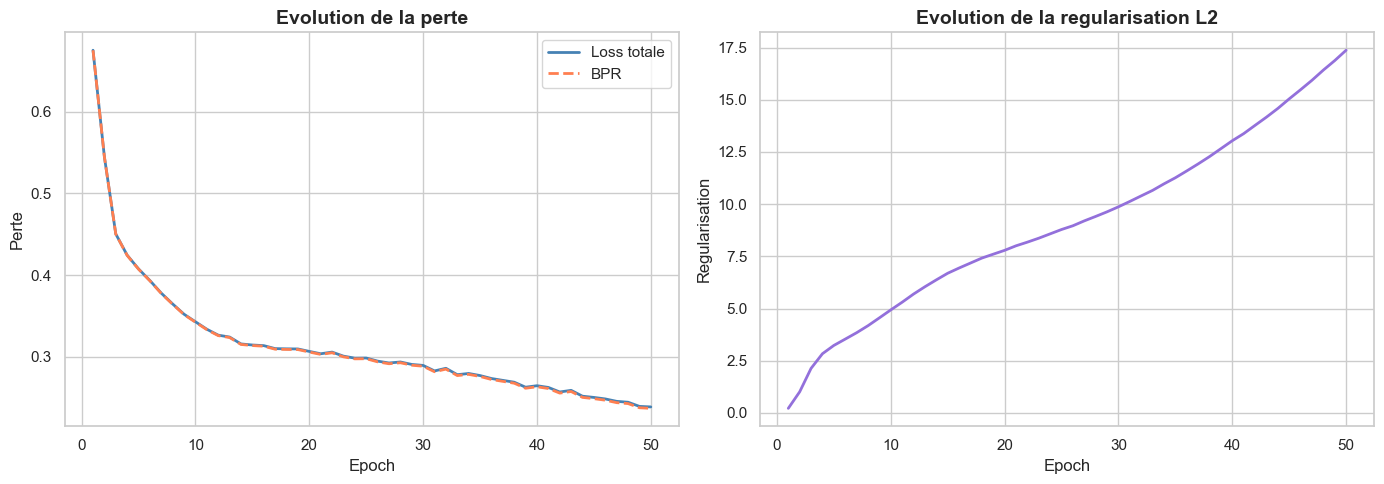

Courbes sauvegardées


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, N_EPOCHS + 1)

# Graphique 1 : Loss totale et BPR
axes[0].plot(epochs, history['loss'], label='Loss totale',
             color='steelblue', linewidth=2)
axes[0].plot(epochs, history['bpr'],  label='BPR',
             color='coral', linewidth=2, linestyle='--')
axes[0].set_title('Evolution de la perte', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Perte')
axes[0].legend()

# Graphique 2 : Régularisation
axes[1].plot(epochs, history['reg'], color='mediumpurple', linewidth=2)
axes[1].set_title('Evolution de la regularisation L2',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Regularisation')

plt.tight_layout()
plt.savefig('../data/courbes_apprentissage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Courbes sauvegardées")

## 5. Sauvegarde du modèle

In [43]:
# Sauvegarde du modèle entraîné
checkpoint = {
    'model_state_dict' : model.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'n_users' : n_users,
    'n_movies' : n_movies,
    'embedding_dim' : 64,
    'n_layers' : 3,
    'n_epochs' : N_EPOCHS,
    'final_loss' : history['loss'][-1],
    'history' : history,
}

torch.save(checkpoint, '../models/lightgcn_final.pth')

size = os.path.getsize('../models/lightgcn_final.pth') / 1024
print(f"Modèle sauvegardé : lightgcn_final.pth  ({size:.1f} KB)")
print("Phase 3 terminée")

Modèle sauvegardé : lightgcn_final.pth  (3188.8 KB)
Phase 3 terminée


## _**Phase 4** : Evaluation et analyse_
## 1. Métriques d'évaluation (Recall@K et NDCG@K)
> Recall@K : proportion des films pertinents retrouvés dans les K recommandations.

> NDCG@K : tient compte de la position des films pertinents dans la liste de recommandations. Un film pertinent en position 1 vaut plus qu'en position 10.

In [ ]:
def recall_at_k(recommended, relevant, k):
    recommended_k = set(recommended[:k])
    relevant = set(relevant)
    if len(relevant) == 0:
        return 0.0
    return len(recommended_k & relevant) / len(relevant)


def ndcg_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant = set(relevant)

    # DCG : Discounted Cumulative Gain
    dcg = 0.0
    for i, item in enumerate(recommended_k):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)  # log2(rang + 1)

    # IDCG : DCG idéal (tous les pertinents en tête)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    if idcg == 0:
        return 0.0
    return dcg / idcg


def evaluate(model, adj_matrix, train_user_items,
             test_user_items, n_movies, k=20):
    """
    Evalue le modèle sur le jeu de test.
    Pour chaque utilisateur, génère les Top-K recommandations
    en excluant les films déjà vus dans le train.
    """
    model.eval()
    recalls, ndcgs = [], []

    with torch.no_grad():
        user_emb, movie_emb = model(adj_matrix)

    for user_idx in tqdm(test_user_items.keys(),
                         desc="Evaluation", leave=False):

        # Films pertinents dans le test
        relevant = list(test_user_items[user_idx])
        if len(relevant) == 0:
            continue

        # Score de cet utilisateur pour tous les films
        u_emb  = user_emb[user_idx]
        scores = torch.matmul(u_emb, movie_emb.T).cpu().numpy()

        # Exclure les films déjà vus dans le train
        seen = list(train_user_items.get(user_idx, set()))
        scores[seen] = -np.inf

        # Top-K recommandations
        top_k = np.argsort(scores)[::-1][:k]

        recalls.append(recall_at_k(top_k, relevant, k))
        ndcgs.append(ndcg_at_k(top_k, relevant, k))

    return np.mean(recalls), np.mean(ndcgs)

print("Fonctions d'évaluation définies.")

Fonctions d'évaluation définies.


## 2. Evaluation sur le jeu de test

In [54]:
# Evaluation pour K = 10 et K = 20
print("Evaluation en cours...")
print()

recall_10, ndcg_10 = evaluate(
    model, adj_matrix, train_user_items,
    test_user_items, n_movies, k=10
)

recall_20, ndcg_20 = evaluate(
    model, adj_matrix, train_user_items,
    test_user_items, n_movies, k=20
)


print(" RESULTATS SUR LE JEU DE TEST")

print(f"\n Recall@10 : {recall_10:.4f}  ({recall_10*100:.2f}%)")
print(f" NDCG@10 : {ndcg_10:.4f}  ({ndcg_10*100:.2f}%)")
print()
print(f" Recall@20 : {recall_20:.4f}  ({recall_20*100:.2f}%)")
print(f" NDCG@20 : {ndcg_20:.4f}  ({ndcg_20*100:.2f}%)")


Evaluation en cours...



 RESULTATS SUR LE JEU DE TEST

 Recall@10 : 0.0492  (4.92%)
 NDCG@10 : 0.0587  (5.87%)

 Recall@20 : 0.0856  (8.56%)
 NDCG@20 : 0.0702  (7.02%)


## 3. Visualisation des métriques

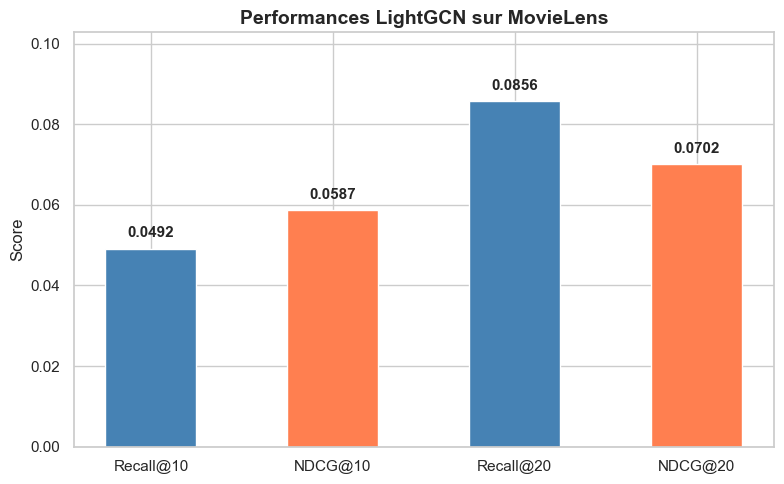

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))

metriques = ['Recall@10', 'NDCG@10', 'Recall@20', 'NDCG@20']
valeurs   = [recall_10, ndcg_10, recall_20, ndcg_20]
couleurs  = ['steelblue', 'coral', 'steelblue', 'coral']

bars = ax.bar(metriques, valeurs, color=couleurs,
              edgecolor='white', width=0.5)

# Valeurs au dessus des barres
for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Performances LightGCN sur MovieLens',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, max(valeurs) * 1.2)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.savefig('../data/metriques_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Génération des recommandations Top-K

In [59]:
def recommander(user_idx, model, adj_matrix, train_user_items,
                idx2movie, movies, k=10):
    """
    Génère les Top-K recommandations pour un utilisateur.
    """
    model.eval()
    with torch.no_grad():
        user_emb, movie_emb = model(adj_matrix)

    # Scores pour tous les films
    u_emb = user_emb[user_idx]
    scores = torch.matmul(u_emb, movie_emb.T).cpu().numpy()

    # Exclure les films déjà vus
    seen = list(train_user_items.get(user_idx, set()))
    scores[seen] = -np.inf

    # Top-K
    top_k = np.argsort(scores)[::-1][:k]

    # Récupération des titres
    resultats = []
    for rank, movie_idx in enumerate(top_k, 1):
        original_id = idx2movie[movie_idx]
        row = movies[movies['movieId'] == original_id]
        title = row['title'].values[0]
        genres = row['genres'].values[0]
        score = scores[movie_idx]
        resultats.append((rank, title, genres, score))

    return resultats

# Test sur 3 utilisateurs différents 
for test_user in [0, 10, 50]:
    print(f"")
    print(f"- TOP 10 RECOMMANDATIONS UTILISATEUR {test_user}")

    # Films vus dans le train
    films_vus = list(train_user_items[test_user])
    print(f" Films vus dans le train : {len(films_vus)}")

    # Films pertinents dans le test
    films_test = list(test_user_items.get(test_user, []))
    print(f" Films pertinents test : {len(films_test)}")
    print()

    # Recommandations
    recs = recommander(test_user, model, adj_matrix,
                       train_user_items, idx2movie, movies, k=10)

    print(f" {'Rang'} - {'Titre'} - {'Genres'} - {'Score'}")
    for rank, title, genres, score in recs:
        print(f" {rank} - {title[:44]} - {genres[:29]} - {score:.4f}")
    print()


- TOP 10 RECOMMANDATIONS UTILISATEUR 0
 Films vus dans le train : 181
 Films pertinents test : 24

 Rang - Titre - Genres - Score
 1 - Independence Day (a.k.a. ID4) (1996) - Action|Adventure|Sci-Fi|Thril - 6.7589
 2 - Silence of the Lambs, The (1991) - Crime|Horror|Thriller - 6.4936
 3 - Terminator 2: Judgment Day (1991) - Action|Sci-Fi - 6.1457
 4 - Terminator, The (1984) - Action|Sci-Fi|Thriller - 6.1382
 5 - Godfather, The (1972) - Crime|Drama - 6.1196
 6 - Back to the Future (1985) - Adventure|Comedy|Sci-Fi - 6.1017
 7 - Austin Powers: The Spy Who Shagged Me (1999) - Action|Adventure|Comedy - 6.0605
 8 - Shawshank Redemption, The (1994) - Crime|Drama - 5.8786
 9 - Groundhog Day (1993) - Comedy|Fantasy|Romance - 5.7794
 10 - Die Hard (1988) - Action|Crime|Thriller - 5.6139


- TOP 10 RECOMMANDATIONS UTILISATEUR 10
 Films vus dans le train : 49
 Films pertinents test : 7

 Rang - Titre - Genres - Score
 1 - Batman (1989) - Action|Crime|Thriller - 7.1951
 2 - Pulp Fiction (1994) - Co

## 5. Visualisation t-SNE des embeddings

Calcul t-SNE en cours...
t-SNE terminé 


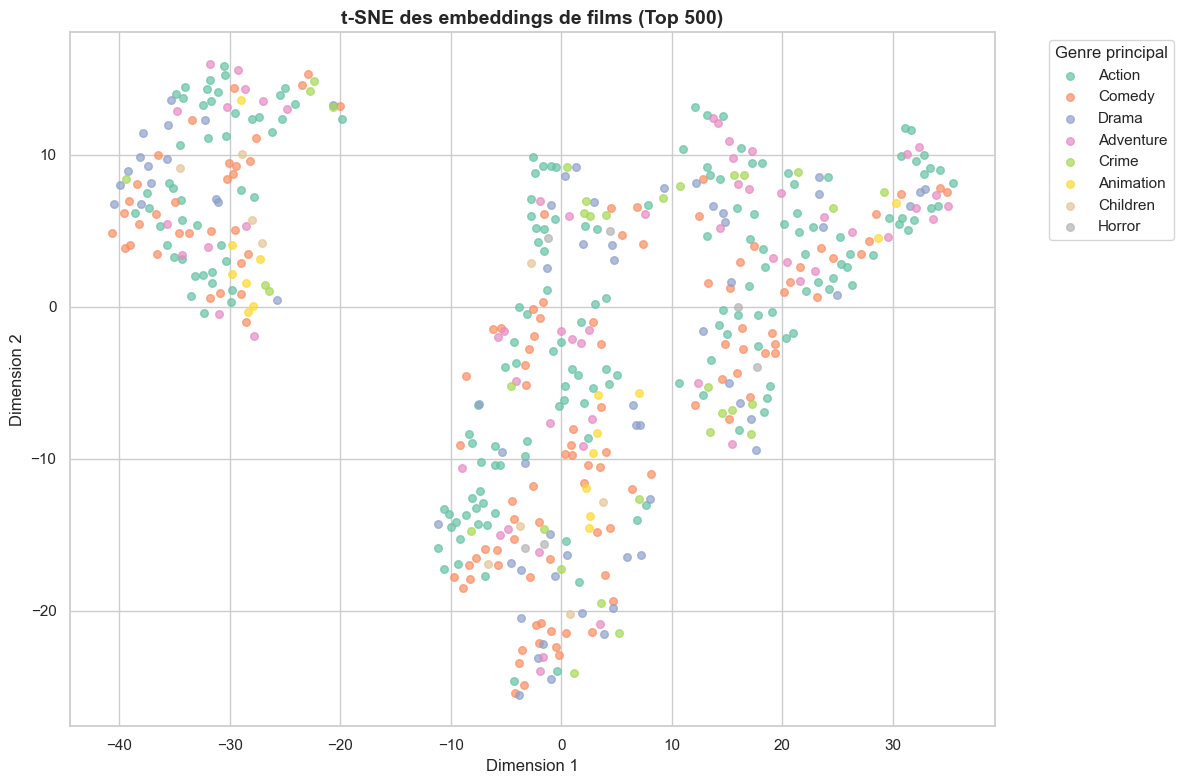

t-SNE sauvegardé.
Phase 4 terminée.


In [62]:
# Récupération des embeddings finaux
model.eval()
with torch.no_grad():
    user_emb_final, movie_emb_final = model(adj_matrix)

user_emb_np = user_emb_final.cpu().numpy()
movie_emb_np = movie_emb_final.cpu().numpy()

# t-SNE sur un échantillon de films
# On prend les 500 films les plus notés pour la lisibilité
top_500_movies = (train_df.groupby('movie_idx')
                          .size()
                          .sort_values(ascending=False)
                          .head(500)
                          .index.tolist())

sample_emb = movie_emb_np[top_500_movies]

# Récupération des genres principaux pour la couleur
genre_list = []
for idx in top_500_movies:
    original_id = idx2movie[idx]
    genres = movies[movies['movieId'] == original_id]['genres'].values[0]
    genre_list.append(genres.split('|')[0])

# t-SNE en 2D
print("Calcul t-SNE en cours...")
tsne   = TSNE(n_components=2, random_state=SEED,
              perplexity=30, n_iter=1000)
emb_2d = tsne.fit_transform(sample_emb)
print("t-SNE terminé ")

# Visualisation
# Top genres les plus fréquents
top_genres = pd.Series(genre_list).value_counts().head(8).index.tolist()
colors = plt.cm.Set2(np.linspace(0, 1, len(top_genres)))
genre2color = {g: c for g, c in zip(top_genres, colors)}

fig, ax = plt.subplots(figsize=(12, 8))

for genre in top_genres:
    mask = [g == genre for g in genre_list]
    x = emb_2d[mask, 0]
    y = emb_2d[mask, 1]
    ax.scatter(x, y, label=genre, alpha=0.7, s=30,
               color=genre2color[genre])

ax.set_title('t-SNE des embeddings de films (Top 500)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.legend(title='Genre principal', bbox_to_anchor=(1.05, 1),
          loc='upper left')

plt.tight_layout()
plt.savefig('../data/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("t-SNE sauvegardé.")
print("Phase 4 terminée.")
